<a href="https://colab.research.google.com/github/anuradhav912-maker/Pet-tech/blob/main/NEWS_category_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TITLE
News Category Classification using NLP and Machine Learning


 Project Description

This project focuses on classifying news articles into different categories
using Natural Language Processing (NLP) and Machine Learning algorithms.

Multiple machine learning algorithms will be trained and evaluated to identify
the best-performing model for news category classification.

 Objective

- To preprocess and clean news text using NLP techniques.
- To convert text into numerical features using TF-IDF.
- To train multiple machine learning classification algorithms.
- To compare the performance of different algorithms.
- To identify the best-performing model.
- To predict the category of new news articles.

In [1]:
#python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#NLP libraries
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

##  Download NLP Resources

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

##  Load the Dataset

## Dataset Download

In [8]:
!wget -q https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
!wget -q https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv

##Load Dataset

In [9]:
train_data = pd.read_csv("train.csv", header=None)
test_data = pd.read_csv("test.csv", header=None)

print("Train dataset loaded successfully")
print("Test dataset loaded successfully")

Train dataset loaded successfully
Test dataset loaded successfully


## Check Dataset

In [10]:
print(train_data.shape)
print(train_data.head())

(120000, 3)
   0                                                  1  \
0  3  Wall St. Bears Claw Back Into the Black (Reuters)   
1  3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2  3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3  3  Iraq Halts Oil Exports from Main Southern Pipe...   
4  3  Oil prices soar to all-time record, posing new...   

                                                   2  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


## Add Column Names

In [11]:
train_data.columns = ["category", "title", "description"]
test_data.columns = ["category", "title", "description"]

## Check Columns

In [12]:
print(train_data.columns)

Index(['category', 'title', 'description'], dtype='object')


## 6. Understand the Dataset

## Check dataset shape

In [13]:
print("Training dataset shape:", train_data.shape)
print("Testing dataset shape:", test_data.shape)

Training dataset shape: (120000, 3)
Testing dataset shape: (7600, 3)


In [14]:
train_data.head()

,category,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [15]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   category     120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


## Check missing values

In [16]:
print(train_data.isnull().sum())

category       0
title          0
description    0
dtype: int64


## Check news Ctegory

In [17]:
print(train_data["category"].value_counts())

category
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


## 7. Data Visualization

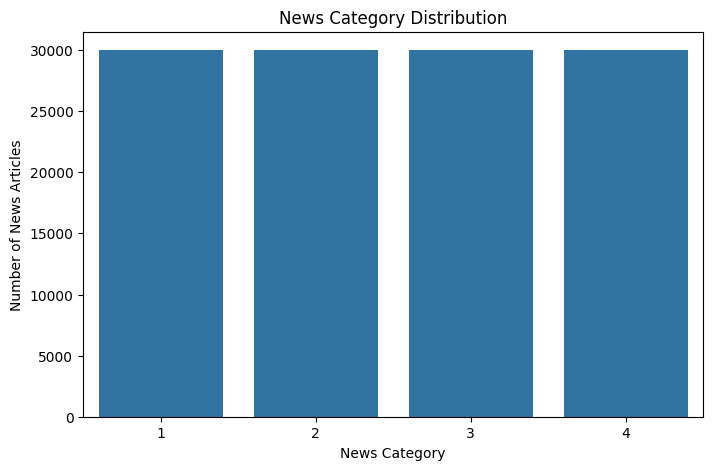

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(x="category", data=train_data)

plt.title("News Category Distribution")
plt.xlabel("News Category")
plt.ylabel("Number of News Articles")
plt.show()

In [19]:
train_data["category"].value_counts()

,count
category,
3,30000
4,30000
2,30000
1,30000


## 8. Combine Title and Description

In [20]:
train_data["text"] = train_data["title"] + " " + train_data["description"]
test_data["text"] = test_data["title"] + " " + test_data["description"]

In [21]:
train_data[["title", "description", "text"]].head()

,title,description,text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


## 9. Text Cleaning

In [22]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [23]:
train_data["clean_text"] = train_data["text"].apply(clean_text)
test_data["clean_text"] = test_data["text"].apply(clean_text)

In [24]:
train_data[["text", "clean_text"]].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to alltime record posing new m...


## 10. Stopword Removal and Lemmatization

In [25]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [26]:
train_data["processed_text"] = train_data["clean_text"].apply(preprocess_text)
test_data["processed_text"] = test_data["clean_text"].apply(preprocess_text)

In [27]:
train_data[["clean_text", "processed_text"]].head()

,clean_text,processed_text
0,wall st bears claw back into the black reuters...,wall st bear claw back black reuters reuters s...
1,carlyle looks toward commercial aerospace reut...,carlyle look toward commercial aerospace reute...
2,oil and economy cloud stocks outlook reuters r...,oil economy cloud stock outlook reuters reuter...
3,iraq halts oil exports from main southern pipe...,iraq halt oil export main southern pipeline re...
4,oil prices soar to alltime record posing new m...,oil price soar alltime record posing new menac...


## 11. Prepare Features and Target

In [28]:
X = train_data["processed_text"]
y = train_data["category"]

## 12. Split the Dataset

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96000
Testing samples: 24000


## 13. TF-IDF Vectorization

In [31]:
tfidf = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (96000, 10000)
Testing TF-IDF shape: (24000, 10000)


## 14. Model 1 - Logistic Regression

In [33]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_logistic = logistic_model.predict(X_test_tfidf)

In [35]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.917


## 15. Model 2 - Multinomial Naive Bayes

In [36]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [37]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [38]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.904875


## 16. Model 3 - Linear SVM

In [39]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [40]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [41]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.9167083333333333


## 17. Model 4 - Random Forest

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [43]:
y_pred_rf = rf_model.predict(X_test_tfidf)

In [44]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8874583333333333


## 18. Model Performance Comparison

In [45]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.917000
1,Naive Bayes,0.904875
2,Linear SVM,0.916708
3,Random Forest,0.887458


In [46]:
model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)

model_results

,Model,Accuracy
0,Logistic Regression,0.917000
2,Linear SVM,0.916708
1,Naive Bayes,0.904875
3,Random Forest,0.887458


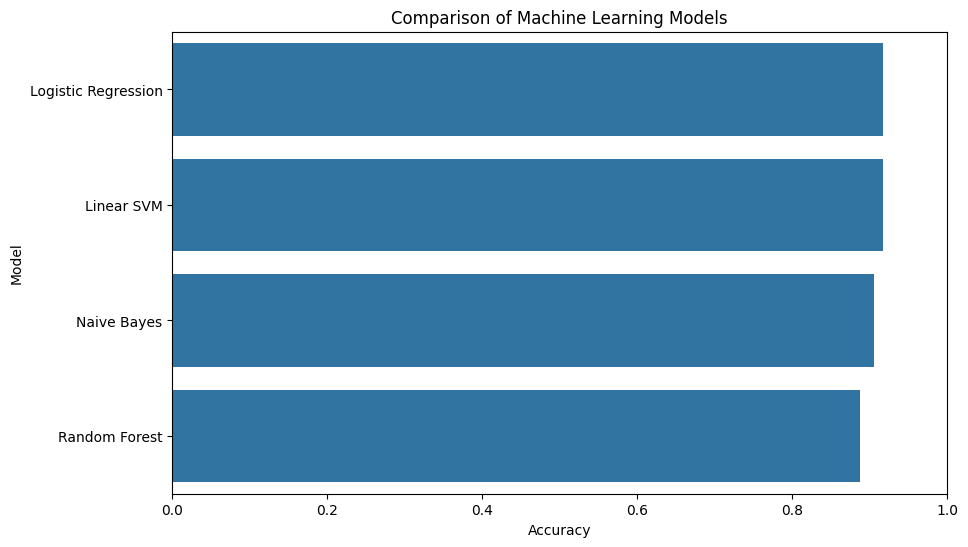

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=model_results
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

In [48]:
best_model = model_results.iloc[0]

print("Best Performing Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Performing Model: Logistic Regression
Best Accuracy: 0.917


## 19. Detailed Model Evaluation

In [49]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))

print("Linear SVM")
print(classification_report(y_test, y_pred_svm))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           1       0.93      0.90      0.91      6000
           2       0.95      0.98      0.97      6000
           3       0.89      0.89      0.89      6000
           4       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000

Naive Bayes
              precision    recall  f1-score   support

           1       0.92      0.89      0.90      6000
           2       0.95      0.98      0.96      6000
           3       0.88      0.87      0.87      6000
           4       0.88      0.88      0.88      6000

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000

Linear SVM
              precision    recall  f1-score   support

           1       0.93      0.9

## 20. F1-Score Comparison

In [50]:
from sklearn.metrics import f1_score

f1_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic, average="weighted"),
        f1_score(y_test, y_pred_nb, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted")
    ]
})

f1_results = f1_results.sort_values(
    by="F1 Score",
    ascending=False
)

f1_results

,Model,F1 Score
0,Logistic Regression,0.916821
2,Linear SVM,0.916529
1,Naive Bayes,0.904614
3,Random Forest,0.887071


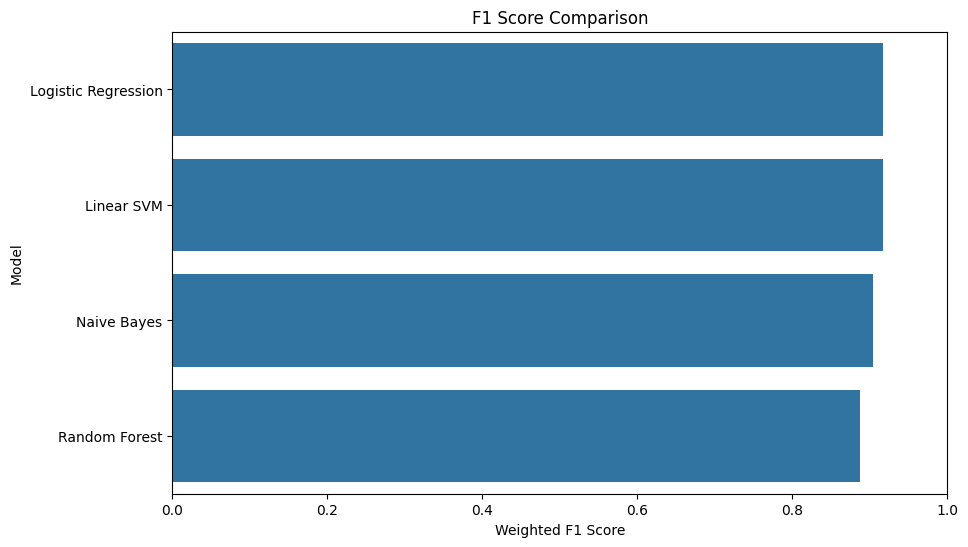

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="F1 Score",
    y="Model",
    data=f1_results
)

plt.title("F1 Score Comparison")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

## 21. Confusion Matrix

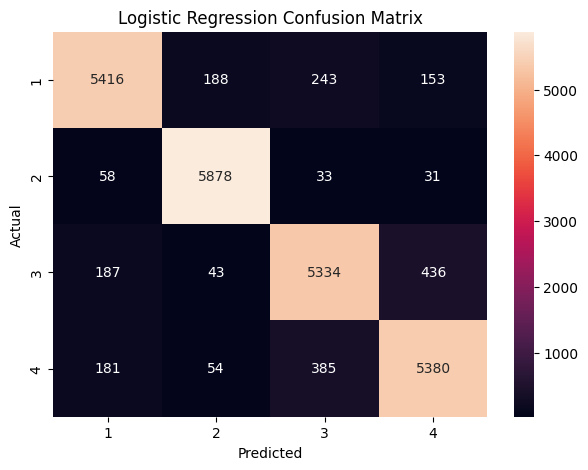

In [52]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

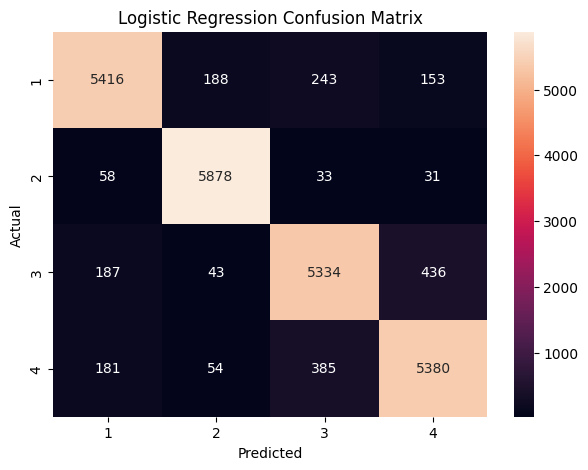

In [53]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

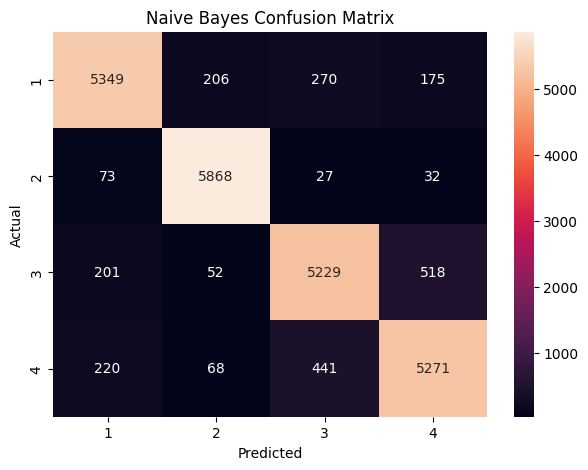

In [54]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

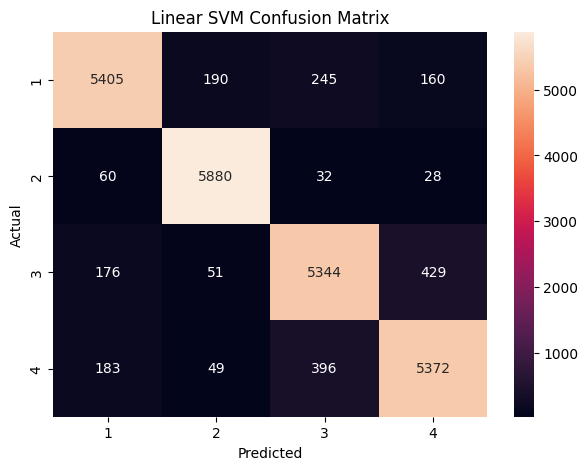

In [55]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

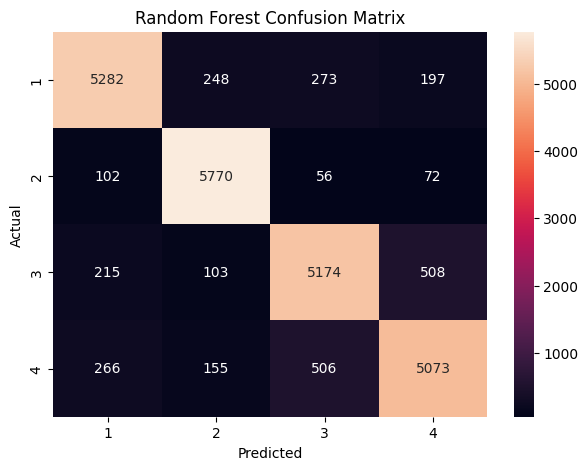

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 22. Select the Best Model

In [57]:
best_model_name = model_results.iloc[0]["Model"]

print("Best Performing Model:", best_model_name)
print("Best Accuracy:", model_results.iloc[0]["Accuracy"])

Best Performing Model: Logistic Regression
Best Accuracy: 0.917


## 23. Predict New News Article

In [58]:
def predict_news(news):
    cleaned_news = clean_text(news)
    processed_news = preprocess_text(cleaned_news)
    news_tfidf = tfidf.transform([processed_news])

    if best_model_name == "Logistic Regression":
        prediction = logistic_model.predict(news_tfidf)

    elif best_model_name == "Naive Bayes":
        prediction = nb_model.predict(news_tfidf)

    elif best_model_name == "Linear SVM":
        prediction = svm_model.predict(news_tfidf)

    else:
        prediction = rf_model.predict(news_tfidf)

    return prediction[0]

In [59]:
news = "The Indian cricket team won the match by defeating Australia"

prediction = predict_news(news)

print("News:", news)
print("Predicted Category:", prediction)

News: The Indian cricket team won the match by defeating Australia
Predicted Category: 2


In [60]:
news = "The company announced a new artificial intelligence technology"

prediction = predict_news(news)

print("News:", news)
print("Predicted Category:", prediction)

News: The company announced a new artificial intelligence technology
Predicted Category: 4


## 24. Save the Best Model

In [61]:
import joblib

In [62]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [63]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Naive Bayes":
    best_model = nb_model

elif best_model_name == "Linear SVM":
    best_model = svm_model

else:
    best_model = rf_model

joblib.dump(best_model, "best_news_classifier.pkl")

['best_news_classifier.pkl']

In [64]:
import os

print("Saved files:")
print(os.listdir())

Saved files:
['.config', 'test.csv.1', 'train.csv.1', 'train.csv', 'best_news_classifier.pkl', 'tfidf_vectorizer.pkl', 'test.csv', 'sample_data']


## 25. Conclusion

This project successfully classifies news articles into different categories
using Natural Language Processing and Machine Learning techniques.

TF-IDF was used to convert textual data into numerical features. Four
machine learning algorithms, namely Logistic Regression, Multinomial Naive
Bayes, Linear SVM, and Random Forest, were trained and evaluated.

The models were compared using accuracy, precision, recall, and F1-score.
The best-performing model was selected based on its classification
performance and used to predict the category of new news articles.

This project demonstrates how NLP and machine learning can be combined
to build an automated news classification system.